# Tourism and Economic Impact - Data Analysis

## 1. Dataset Selection

The dataset used in this project is the **Tourism and Economic Impact Dataset**,
available on Kaggle.

- **Topic:** International tourism statistics and economic indicators
- **Source:** World Bank data, compiled on Kaggle by Bushra Qurban
- **Rows:** 6,650
- **Columns:** 11
- **Years covered:** 1999 to 2023
- **Countries:** 266

**Why I chose this dataset:**
I chose this dataset because tourism reflects real world events.
The data covers 25 years and shows how crises like COVID-19
affected countries around the world.

In [41]:
# Import tools
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 2. Data Understanding and Cleaning

In this section I loaded the dataset and inspected its structure.
I checked the first rows, the data types of each column,
and identified missing values.

The dataset has missing values in several columns, especially
in tourism_departures (4,061 missing) and unemployment (2,992 missing).
This is normal for real world data collected across many countries.

In [42]:
# Read file
df = pd.read_csv("world_tourism_economy_data.csv")
print("File loaded!", df.shape)

File loaded! (6650, 11)


In [43]:
# Inspect the data
df.head()

,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,Aruba,ABW,1999,7.820000e+08,9.720000e+05,62.542949,NaN,9.495387,1.722905e+09,2.280372,NaN
1,Africa Eastern and Southern,AFE,1999,8.034209e+09,1.530938e+07,12.204030,NaN,7.760536,2.654293e+11,7.819865,NaN
2,Afghanistan,AFG,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1999,1.443613e+09,3.897975e+06,3.974476,NaN,6.147291,1.394683e+11,0.372266,NaN
4,Angola,AGO,1999,3.100000e+07,4.500000e+04,0.583858,NaN,2.489638,6.152923e+09,248.195902,NaN


In [44]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               6650 non-null   object 
 1   country_code          6650 non-null   object 
 2   year                  6650 non-null   int64  
 3   tourism_receipts      4289 non-null   float64
 4   tourism_arrivals      4949 non-null   float64
 5   tourism_exports       4114 non-null   float64
 6   tourism_departures    2589 non-null   float64
 7   tourism_expenditures  4173 non-null   float64
 8   gdp                   6424 non-null   float64
 9   inflation             5668 non-null   float64
 10  unemployment          3658 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 571.6+ KB


In [45]:
# Basic statistics
df.describe()

,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
count,6650.000000,4.289000e+03,4.949000e+03,4114.000000,2.589000e+03,4173.000000,6.424000e+03,5668.000000,3658.000000
mean,2011.000000,3.062956e+10,6.263894e+07,15.506851,8.246093e+07,6.652740,2.089999e+12,6.319369,7.961191
std,7.211645,1.291076e+11,2.049444e+08,17.758374,2.064665e+08,4.071632,7.761985e+12,18.682769,5.802565
min,1999.000000,1.000000e+05,9.000000e+02,0.000956,2.000000e+03,0.157818,1.396473e+07,-16.859691,0.039000
25%,2005.000000,2.690000e+08,5.290000e+05,4.657732,1.051000e+06,4.074702,6.087182e+09,1.865425,4.250000
50%,2011.000000,1.553000e+09,2.508000e+06,8.306797,4.634000e+06,5.754790,3.681803e+10,3.629433,6.548000
75%,2017.000000,9.144227e+09,1.818000e+07,18.506710,4.508703e+07,7.985102,4.266977e+11,6.563197,9.894692
max,2023.000000,1.863069e+12,2.403074e+09,101.966999,2.034432e+09,28.192276,1.061717e+14,557.201817,57.000000


In [46]:
# Check missing values
df.isnull().sum()

country                    0
country_code               0
year                       0
tourism_receipts        2361
tourism_arrivals        1701
tourism_exports         2536
tourism_departures      4061
tourism_expenditures    2477
gdp                      226
inflation                982
unemployment            2992
dtype: int64

### Data Cleaning

I removed rows where the key columns tourism_arrivals and 
tourism_receipts had missing values.

- Before cleaning: 6,650 rows
- After cleaning: 3,921 rows
- Rows removed: 2,729

This is expected in real world data, as not all countries 
report tourism statistics every year.

In [47]:
# Clean the data - remove rows where key columns are missing
df_clean = df.dropna(subset=['tourism_arrivals', 'tourism_receipts'])
print("Rows before cleaning:", df.shape)
print("Rows after cleaning:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Rows before cleaning: (6650, 11)
Rows after cleaning: (3921, 11)
Rows removed: 2729


## 3. Measures of Central Tendency

I calculated the mean, median and mode for tourism_arrivals 
and tourism_receipts.

**Results:**
- Mean of arrivals: 62.6 million
- Median of arrivals: 2.5 million
- Mode of arrivals: 60,000

**Are the values similar or different?**
The values are very different. The mean is 25 times higher 
than the median. This is a big difference.

**What does this mean about the distribution?**
This means the data is right-skewed. A small number of very 
popular countries like France, USA and China receive billions 
of tourists, pulling the mean up. Most countries receive 
far fewer tourists than the average suggests.
In a right-skewed distribution, the mean is always higher 
than the median — and that is exactly what we see here.

In [48]:
# Section 3 - Measures of Central Tendency
print("TOURISM ARRIVALS:")
print("Mean:", df['tourism_arrivals'].mean())
print("Median:", df['tourism_arrivals'].median())
print("Mode:", df['tourism_arrivals'].mode()[0])

print("\nTOURISM RECEIPTS:")
print("Mean:", df['tourism_receipts'].mean())
print("Median:", df['tourism_receipts'].median())
print("Mode:", df['tourism_receipts'].mode()[0])

TOURISM ARRIVALS:
Mean: 62638935.88873551
Median: 2508000.0
Mode: 60000.0

TOURISM RECEIPTS:
Mean: 30629563076.77851
Median: 1553000000.0
Mode: 76000000.0


## 4. Measures of Spread / Dispersion

I calculated the range, IQR, variance and standard deviation
for tourism_arrivals.

**Results:**
- Min: 900 arrivals
- Max: 2.4 billion arrivals
- Range: 2.4 billion
- Standard Deviation: 204 million
- IQR: 17.6 million

**What this tells us:**
The data is extremely spread out. The enormous range and high 
standard deviation confirm that tourism is very unequal worldwide.
A few large countries dominate, while most countries receive 
very few tourists. The tourism_arrivals column has the highest 
variability in the dataset.

In [49]:
# Section 4 - Measures of Spread
print("TOURISM ARRIVALS:")
print("Min:", df['tourism_arrivals'].min())
print("Max:", df['tourism_arrivals'].max())
print("Range:", df['tourism_arrivals'].max() - df['tourism_arrivals'].min())
print("Variance:", df['tourism_arrivals'].var())
print("Std Deviation:", df['tourism_arrivals'].std())
print("IQR:", df['tourism_arrivals'].quantile(0.75) - df['tourism_arrivals'].quantile(0.25))

TOURISM ARRIVALS:
Min: 899.999976158142
Max: 2403074088.46029
Range: 2403073188.460314
Variance: 4.200221646330279e+16
Std Deviation: 204944422.8645971
IQR: 17651000.0


## 5. Data Visualization

### Visualization 1 - Histogram: Distribution of Tourism Arrivals

**Columns used:** tourism_arrivals
**Why this column:** It is the main indicator of tourism activity
**Why a histogram:** To show how tourism arrivals are distributed 
across all countries
**What it shows:** Most countries receive very few tourists. 
The distribution is heavily right-skewed, with a few outliers 
receiving billions of arrivals.

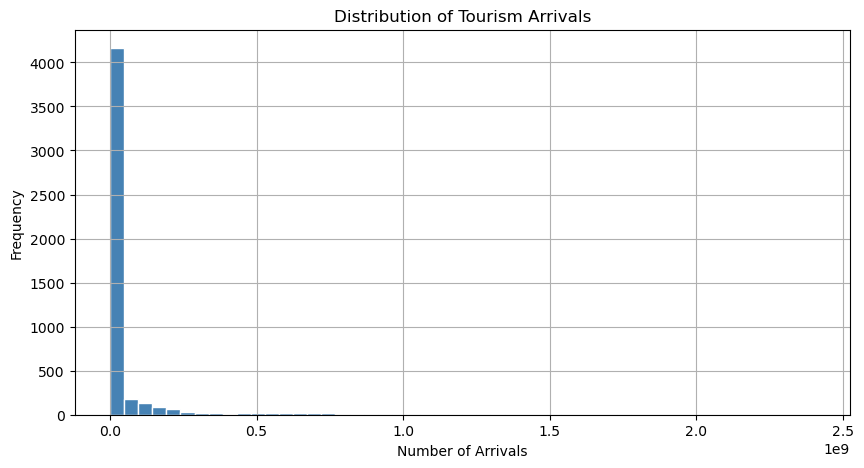

In [50]:
# Section 5 - Visualization 1: Histogram of Tourism Arrivals
plt.figure(figsize=(10,5))
plt.hist(df['tourism_arrivals'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title("Distribution of Tourism Arrivals")
plt.xlabel("Number of Arrivals")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### Visualization 2 - Box Plot: Tourism Receipts by Decade

**Columns used:** tourism_receipts, decade
**Why these columns:** To compare economic impact of tourism over time
**Why a box plot:** To show the spread and outliers in each decade
**What it shows:** Tourism receipts grew every decade. The 2010s 
had the most outliers — countries earning billions from tourism.
The 2020s show a drop due to COVID-19.

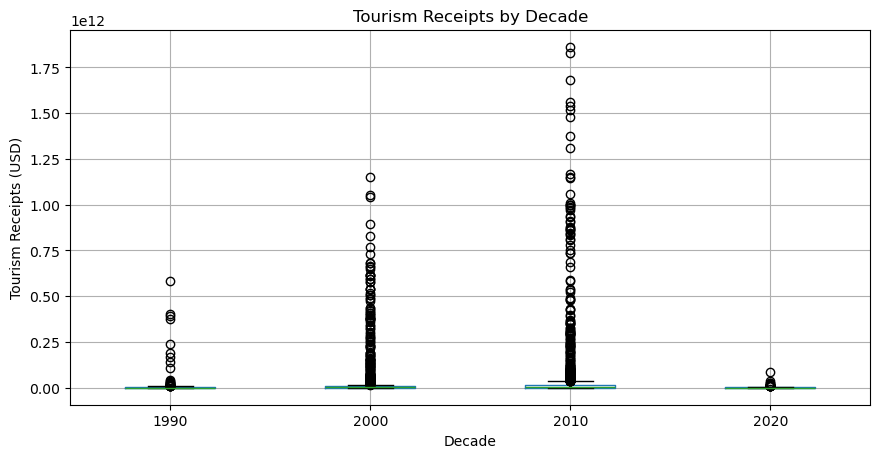

In [51]:
# Visualization 2: Box Plot of Tourism Receipts by decade
df['decade'] = (df['year'] // 10) * 10
df.boxplot(column='tourism_receipts', by='decade', figsize=(10,5))
plt.title("Tourism Receipts by Decade")
plt.suptitle("")
plt.xlabel("Decade")
plt.ylabel("Tourism Receipts (USD)")
plt.grid(True)
plt.show()

### Visualization 3 - Line Chart: Global Tourism Arrivals Over Time

- **Columns used:** year, tourism_arrivals
- **Why these columns:** To show the evolution of tourism over 25 years
- **Why a line chart:** A line chart is the best way to show trends 
  over time. It makes it easy to see growth and drops clearly.
- **What it shows:** Tourism grew consistently from 1999 to 2019. 
  In 2020, there was a dramatic drop due to COVID-19. 
  Recovery started in 2021 but is still below pre-pandemic levels.

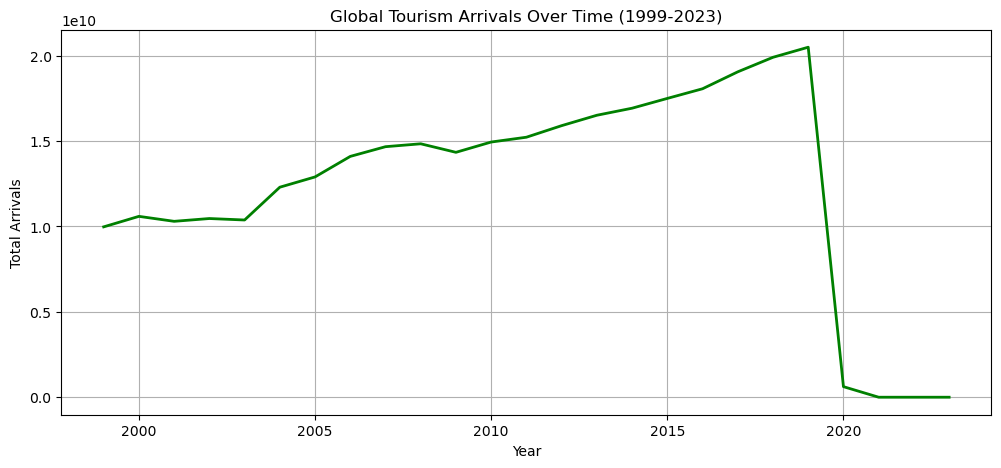

In [52]:
# Visualization 3: Global tourism arrivals over time
arrivals_by_year = df.groupby('year')['tourism_arrivals'].sum()

plt.figure(figsize=(12,5))
plt.plot(arrivals_by_year.index, arrivals_by_year.values, color='green', linewidth=2)
plt.title("Global Tourism Arrivals Over Time (1999-2023)")
plt.xlabel("Year")
plt.ylabel("Total Arrivals")
plt.grid(True)
plt.show()

## 6. Interpretation and Summary

Below is a summary of the main findings from this analysis.

## 6. Interpretation and Summary

Below is a summary of the main findings from this analysis.

**What did I learn from the statistics?**
The mean is much higher than the median, which shows that 
tourism is very unequal. A few large countries dominate 
global tourism while most countries receive very few visitors.

**What did I learn from the visualizations?**
The line chart was the most powerful visualization. It clearly 
shows the dramatic drop in global tourism in 2020 due to COVID-19.
The bar chart confirmed that France, USA and China are the 
most visited countries in the world.

**Were there any surprising patterns, outliers or trends?**
Yes! Two things surprised me:

1. The speed of the COVID drop — in just one year, global 
tourism collapsed to almost zero. This was faster and bigger 
than the 2008 financial crisis drop.

2. France as the number one country — France is much smaller 
than China or the USA, but receives more tourists than both.
This shows that cultural heritage and quality of experience 
matter more than country size.

## Curiosity

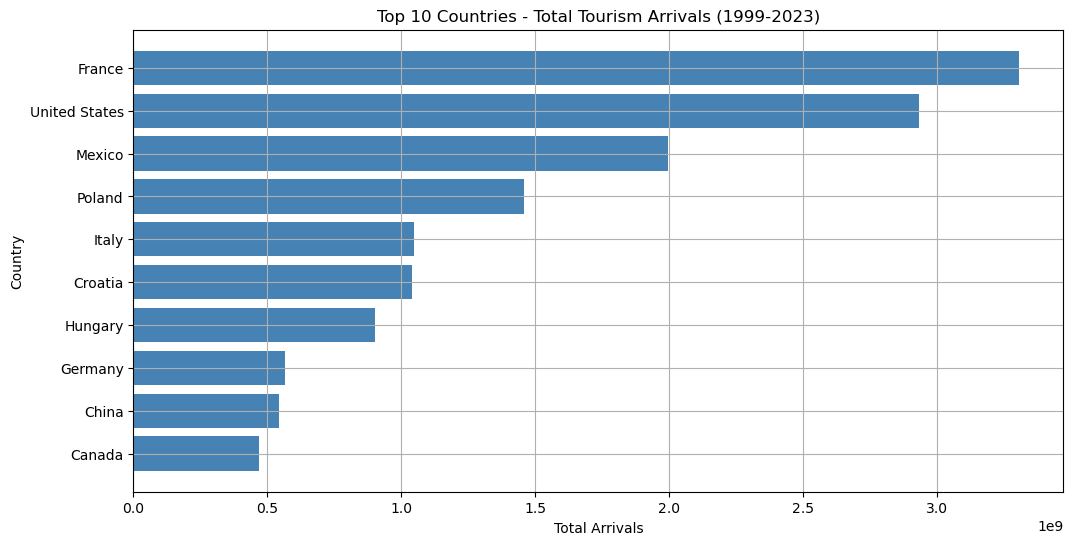

In [53]:
# Visualization 4: Top 10 Countries (using clean data)
keep = ['France', 'United States', 'China', 'Spain', 'Italy', 
        'Mexico', 'Turkey', 'Germany', 'United Kingdom', 'Greece',
        'Austria', 'Japan', 'Poland', 'Canada', 'Croatia',
        'Hungary', 'Portugal', 'Thailand', 'Netherlands', 'Brazil']

countries_only = df_clean[df_clean['country'].isin(keep)]
top_countries = countries_only.groupby('country')['tourism_arrivals'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top_countries.index, top_countries.values, color='steelblue')
plt.title("Top 10 Countries - Total Tourism Arrivals (1999-2023)")
plt.xlabel("Total Arrivals")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()